# M4.Ex1: Housing Prices Model (PyCaret)

- Run: [**Open In Colab**](https://colab.research.google.com/github/HassanAlgoz/B5/blob/main/content/W3/M6/exercises/ex1_pycaret_regression.ipynb)

## Exercise

Your task is to follow the steps outlined here, and apply them on the **California Housing Dataset** below:

- [**🚀 Regression**](https://pycaret.gitbook.io/docs/get-started/quickstart#regression)
    - Setup
    - Compare Models
    - Analyze Model
    - Predictions
    - Save the model

## California Housing Prices Dataset


Find and download the dataset from Kaggle at [California Housing Dataset](https://www.kaggle.com/datasets/dhirajnirne/california-housing-data).

According to [keras.io](https://keras.io/api/datasets/california_housing/):

> This dataset was obtained from the StatLib repository.
>
> It's a continuous regression dataset with 20,640 samples with 8 features each.
>
> The target variable is a scalar: the median house value for California districts, in dollars.
>
> The 8 input features are the following:
>
> - MedInc: median income in block group
> - HouseAge: median house age in block group
> - AveRooms: average number of rooms per household
> - AveBedrms: average number of bedrooms per household
> - Population: block group population
> - AveOccup: average number of household members
> - Latitude: block group latitude
> - Longitude: block group longitude
>
> This dataset was derived from the 1990 U.S. census, using one row per census block group. A block group is the smallest geographical unit for which the U.S. Census Bureau publishes sample data (a block group typically has a population of 600 to 3,000 people).
>
> A household is a group of people residing within a home. Since the average number of rooms and bedrooms in this dataset are provided per household, these columns may take surprisingly large values for block groups with few households and many empty houses, such as vacation resorts.

In [1]:
!pip install numpy==1.26.4 -q

In [11]:
!pip uninstall -y pycaret
!pip install pycaret==3.3.2

Found existing installation: pycaret 3.3.2
Uninstalling pycaret-3.3.2:
  Successfully uninstalled pycaret-3.3.2
  Using cached pycaret-3.3.2-py3-none-any.whl.metadata (17 kB)
Using cached pycaret-3.3.2-py3-none-any.whl (486 kB)


In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("dhirajnirne/california-housing-data")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'california-housing-data' dataset.
Path to dataset files: /kaggle/input/california-housing-data


In [2]:
import pandas as pd
import os
from sklearn.model_selection import train_test_split

# قراءة الملف من المسار الذي استخرجه kagglehub
csv_path = os.path.join(path, "housing.csv")
df = pd.read_csv(csv_path)

# تحديد الهدف (Target) والميزات (Features)
X = df.drop("median_house_value", axis=1) # كل شيء ما عدا السعر
y = df["median_house_value"]             # السعر المراد التنبؤ به

# تقسيم البيانات (80% تدريب، 20% اختبار)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [3]:
import sys

# Temporarily remove the explicit Python version check in pycaret/__init__.py
# This is a workaround for PyCaret 3.x not officially supporting Python 3.12 yet.
init_file_path = '/usr/local/lib/python3.12/dist-packages/pycaret/__init__.py'

with open(init_file_path, 'r') as f:
    content = f.read()

# Pattern for Python 3.12 incompatibility check
# This needs to cover the entire block, including multi-line arguments
pattern_312 = """elif sys.version_info >= (3, 12):
    raise RuntimeError(
        "Pycaret only supports python 3.9, 3.10, 3.11. Your actual Python version: ",
        sys.version_info,
        "Please DOWNGRADE your Python version.",
    )"""

# Replace the block with a commented version to preserve structure and disable the check
if pattern_312 in content:
    commented_pattern = "\n".join([f"# {line}" for line in pattern_312.splitlines()])
    content = content.replace(pattern_312, commented_pattern)
    print("Python 3.12 version check in PyCaret __init__.py commented out.")
else:
    print("Python 3.12 version check pattern not found in PyCaret __init__.py. (Already patched or different version)")

# Also check for older Python version incompatibility (if any) and comment it out
pattern_old_py = """if sys.version_info < (3, 9):
    raise RuntimeError(
        "Pycaret only supports python 3.9, 3.10, 3.11. Your actual Python version: ",
        sys.version_info,
        "Please UPGRADE your Python version.",
    )"""
if pattern_old_py in content:
    commented_old_py_pattern = "\n".join([f"# {line}" for line in pattern_old_py.splitlines()])
    content = content.replace(pattern_old_py, commented_old_py_pattern)
    print("Older Python version check in PyCaret __init__.py commented out.")


with open(init_file_path, 'w') as f:
    f.write(content)

print("PyCaret __init__.py patching complete.")

Python 3.12 version check in PyCaret __init__.py commented out.
Older Python version check in PyCaret __init__.py commented out.
PyCaret __init__.py patching complete.


,Description,Value
0,Session id,123
1,Target,median_house_value
2,Target type,Regression
3,Original data shape,"(20640, 10)"
4,Transformed data shape,"(20640, 14)"
5,Transformed train set shape,"(14447, 14)"
6,Transformed test set shape,"(6193, 14)"
7,Numeric features,8
8,Categorical features,1
9,Rows with missing values,1.0%


,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
catboost,CatBoost Regressor,30722.6343,2158686221.4324,46430.7954,0.8376,0.2291,0.1707,4.7940
lightgbm,Light Gradient Boosting Machine,32446.5243,2352506625.5720,48484.5478,0.8231,0.2376,0.1806,0.2940
rf,Random Forest Regressor,32601.1401,2500102516.8196,49989.2760,0.8121,0.2415,0.1817,15.6050
et,Extra Trees Regressor,35279.0180,2805036753.3820,52947.4818,0.7892,0.2522,0.1955,5.8560
gbr,Gradient Boosting Regressor,39009.2448,3150819000.1502,56118.7995,0.7633,0.2736,0.2186,3.8310
lr,Linear Regression,50154.1376,4757779475.9005,68960.1376,0.6429,0.3811,0.2885,0.1310
lasso,Lasso Regression,50154.5348,4757787550.5767,68960.2055,0.6429,0.3811,0.2885,0.2380
ridge,Ridge Regression,50155.4032,4757762702.3264,68960.0498,0.6429,0.3810,0.2885,0.1550
llar,Lasso Least Angle Regression,50154.5079,4757786154.0176,68960.1951,0.6429,0.3811,0.2885,0.1100
br,Bayesian Ridge,50167.2546,4759928809.4993,68976.0109,0.6428,0.3809,0.2887,0.1730


Processing:   0%|          | 0/85 [00:00<?, ?it/s]

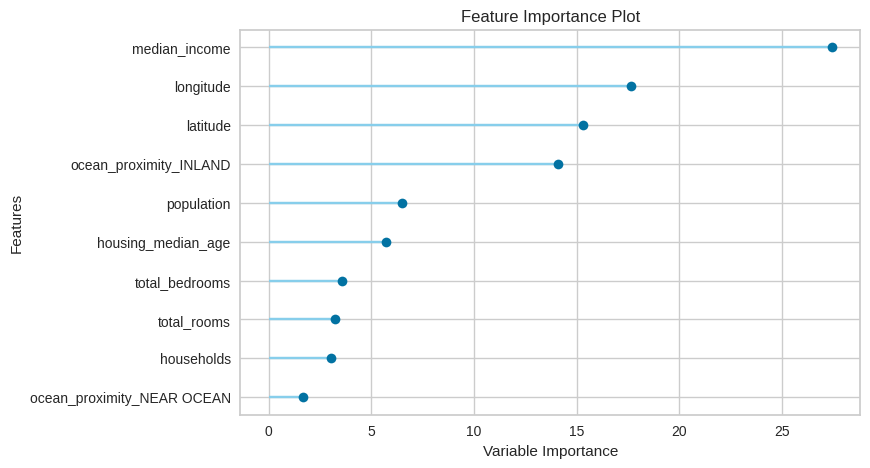

In [4]:
import pycaret
from pycaret.regression import *

# إعداد البيئة
# أضفنا verbose=False لتقليل مخرجات النظام التي قد تسبب تعليق
s = setup(data = df,
          target = 'median_house_value',
          session_id = 123,
          n_jobs = 1) # تحديد عدد المهام بـ 1 يقلل مشاكل الـ AttributeError في Colab

# مقارنة الموديلات
best_model = compare_models()

# عرض النتائج
plot_model(best_model, plot = 'feature')

### Load the data

**Task**: Your model should learn from this data and be able to predict the median housing price (`median_house_value`) in any district, given all the other metrics.

Please read the above dataset description to understand what the features mean.

In [5]:
evaluate_model(best_model)

interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

In [6]:
predictions = predict_model(best_model)
predictions.head()

,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE
0,CatBoost Regressor,29695.4891,1969451412.0598,44378.5017,0.8511,0.2248,0.1681


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity,median_house_value,prediction_label
19121,-122.639999,38.240002,40.0,1974.0,410.0,1039.0,398.0,3.7917,<1H OCEAN,151600.0,201405.051543
20019,-119.050003,36.090000,9.0,3297.0,568.0,1749.0,568.0,4.0217,INLAND,99200.0,96862.509212
15104,-116.980003,32.849998,12.0,3570.0,713.0,3321.0,666.0,4.0882,<1H OCEAN,134500.0,140923.168194
3720,-118.419998,34.200001,27.0,3201.0,970.0,3403.0,948.0,2.2377,<1H OCEAN,231700.0,183494.825426
8938,-118.470001,34.009998,41.0,2704.0,557.0,1047.0,478.0,4.4211,<1H OCEAN,462900.0,428488.669613


In [7]:
save_model(best_model, 'housing_model')

Transformation Pipeline and Model Successfully Saved


(Pipeline(memory=Memory(location=None),
          steps=[('numerical_imputer',
                  TransformerWrapper(include=['longitude', 'latitude',
                                              'housing_median_age',
                                              'total_rooms', 'total_bedrooms',
                                              'population', 'households',
                                              'median_income'],
                                     transformer=SimpleImputer())),
                 ('categorical_imputer',
                  TransformerWrapper(include=['ocean_proximity'],
                                     transformer=SimpleImputer(strategy='most_frequent'))),
                 ('onehot_encoding',
                  TransformerWrapper(include=['ocean_proximity'],
                                     transformer=OneHotEncoder(cols=['ocean_proximity'],
                                                               handle_missing='return_nan',
              